# 第三階段:量化「空間」—— 接球員與最近防守者的距離

**最終目標**:做一個「傳球空間分析」工具,給教練或球探使用。

**本階段只做一件事**:在第二階段切好的 **snap → pass 片段**上,算出每位接球員(跑路線的人)與其**最近防守者**之間的距離,並看這個距離在這幾秒內**怎麼隨時間變化**。

這個「接球員與最近防守者的距離」,在美式足球裡叫 **separation(拉開的空間)**。separation 越大,代表這位接球員越空、越好傳。這是「傳球空間」最基本、最直覺的量化方式。

---

### 這一階段的原則(跟前兩階段一樣)

- **先用資料算、再下結論**。我們只計算距離,不預設任何球員表現好壞。
- 只用**一個** play(`playId=137`)示範,把方法走通,之後才推廣到更多 play。
- 這一階段**還不做**控制區(Voronoi)等更複雜的指標,那是後面的事。

## 步驟 0:載入工具與設定路徑

- **輸入**:無
- **輸出**:`pandas`、`numpy`、`matplotlib`、路徑設定
- **目的**:準備工具。這一階段多用 `numpy` 算距離、`matplotlib` 畫隨時間變化的折線圖。

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 中文字型(macOS 內建),避免圖上中文顯示成方框
plt.rcParams["font.sans-serif"] = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 讓筆記本找得到上一層資料夾裡的 config.py
sys.path.append(str(Path.cwd().parent))
from config import DATA_DIR, SAMPLE_GAME_ID

SAMPLE_PLAY_ID = 137  # 跟第二階段同一個 play(DAL 深傳左路給 A.Cooper)
print("gameId:", SAMPLE_GAME_ID, "/ playId:", SAMPLE_PLAY_ID)

gameId: 2021090900 / playId: 137


## 步驟 1:重建第二階段的 snap → pass 片段

- **輸入**:`tracking`、`plays`、`players`、`pff`
- **輸出**:`dropback_named`(snap 到 pass 之間,每格每人,附人名與角色)
- **目的**:這一階段要直接用第二階段的成果。為了讓這個筆記本能**獨立執行**,這裡用同樣的步驟把片段重建一次。

> 步驟和第二階段完全一樣:篩 play → 找 snap/pass frame → 切片段 → 接人名與角色。這裡壓成一格,細節解說請看 `02_isolate_one_pass_play.ipynb`。

In [2]:
# 讀資料
plays = pd.read_csv(DATA_DIR / "plays.csv")
players = pd.read_csv(DATA_DIR / "players.csv")
pff = pd.read_csv(DATA_DIR / "pffScoutingData.csv")
tracking = pd.read_csv(DATA_DIR / "tracking" / f"tracking_{SAMPLE_GAME_ID}.csv")

this_play = plays[(plays["gameId"] == SAMPLE_GAME_ID) & (plays["playId"] == SAMPLE_PLAY_ID)]

# 篩單一 play 的 tracking
play_track = tracking[
    (tracking["gameId"] == SAMPLE_GAME_ID) & (tracking["playId"] == SAMPLE_PLAY_ID)
].copy()

# 找 snap / pass 的 frameId
snap_frame = play_track.loc[play_track["event"] == "ball_snap", "frameId"].iloc[0]
pass_frame = play_track.loc[play_track["event"] == "pass_forward", "frameId"].iloc[0]

# 切出 snap -> pass 片段
dropback = play_track[
    (play_track["frameId"] >= snap_frame) & (play_track["frameId"] <= pass_frame)
].copy()

# 接人名、位置、角色
play_pff = pff[
    (pff["gameId"] == SAMPLE_GAME_ID) & (pff["playId"] == SAMPLE_PLAY_ID)
][["nflId", "pff_role", "pff_positionLinedUp"]]
dropback_named = (
    dropback
    .merge(players[["nflId", "displayName", "officialPosition"]], on="nflId", how="left")
    .merge(play_pff, on="nflId", how="left")
)

print("snap frame:", snap_frame, "/ pass frame:", pass_frame)
print("片段形狀:", dropback_named.shape, "/ frame 數:", dropback_named["frameId"].nunique())

snap frame: 7 / pass frame: 32
片段形狀: (598, 20) / frame 數: 26


## 步驟 2:分出「接球員」與「防守者」兩組

- **輸入**:`dropback_named` 的 `pff_role`
- **輸出**:`receivers`(跑路線的接球員)、`defenders`(盯人/區域的防守者)
- **目的**:separation 是「接球員 ↔ 防守者」之間的距離,所以要先把這兩組人分開。

**怎麼分?** 用 `pff_role`:
- 接球員 = `pff_role == "Pass Route"`(這個 play 負責跑路線接球的人)。
- 防守者 = `pff_role == "Coverage"`(負責盯人或守區域的防守球員)。

> 這裡**刻意不**把 Pass Block / Pass Rush(鋒線互推)算進來,因為 separation 關心的是「接球員空不空」,鋒線的推擠跟傳球空間無關。

In [3]:
receivers = dropback_named[dropback_named["pff_role"] == "Pass Route"].copy()
defenders = dropback_named[dropback_named["pff_role"] == "Coverage"].copy()

print("接球員(Pass Route)名單:")
print(receivers[["nflId", "displayName", "officialPosition"]].drop_duplicates().to_string(index=False))
print("\n防守者(Coverage)名單:")
print(defenders[["nflId", "displayName", "officialPosition"]].drop_duplicates().to_string(index=False))

print("\n接球員人數:", receivers["nflId"].nunique(), "/ 防守者人數:", defenders["nflId"].nunique())

接球員(Pass Route)名單:
  nflId     displayName officialPosition
42347.0    Amari Cooper               WR
43293.0 Ezekiel Elliott               RB
45532.0    Blake Jarwin               TE
46206.0  Dalton Schultz               TE
52425.0     CeeDee Lamb               WR

防守者(Coverage)名單:
  nflId         displayName officialPosition
38588.0       Lavonte David              ILB
41915.0     Shaquil Barrett              OLB
46132.0       Carlton Davis               CB
47788.0         Devin White              ILB
47822.0 Sean Murphy-Bunting               CB
52453.0    Antoine Winfield               FS

接球員人數: 5 / 防守者人數: 6


## 步驟 3:核心計算 —— 每位接球員、每個時間點,到最近防守者的距離

- **輸入**:`receivers`、`defenders`
- **輸出**:DataFrame `separation`(每位接球員每個 frame 一列,含最近防守者與距離)
- **目的**:這是本階段的重點。

**怎麼算?** 兩點距離用國中就學過的畢氏定理(歐氏距離):

$$\text{距離} = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$$

做法:**對每一個 frame**,拿該 frame 的所有接球員座標、所有防守者座標,算出每位接球員到**每位**防守者的距離,再取**最小值**(最近的那位),就是這位接球員在這一刻的 separation。

In [4]:
rows = []
for frame_id in sorted(dropback_named["frameId"].unique()):
    rec_f = receivers[receivers["frameId"] == frame_id]
    def_f = defenders[defenders["frameId"] == frame_id]
    def_xy = def_f[["x", "y"]].to_numpy()        # 這一格所有防守者座標
    def_names = def_f["displayName"].to_numpy()

    for _, r in rec_f.iterrows():
        # 這位接球員到每位防守者的距離
        dists = np.sqrt((def_xy[:, 0] - r["x"]) ** 2 + (def_xy[:, 1] - r["y"]) ** 2)
        nearest = int(np.argmin(dists))           # 最近那位的索引
        rows.append({
            "frameId": frame_id,
            # 相對發球的秒數:每格 0.1 秒
            "seconds_since_snap": round((frame_id - snap_frame) * 0.1, 1),
            "receiver": r["displayName"],
            "nearest_defender": def_names[nearest],
            "separation_yd": round(float(dists[nearest]), 2),
        })

separation = pd.DataFrame(rows)
print("separation 形狀:", separation.shape)
print("(應該 = 接球員數 ×  frame 數 =", receivers["nflId"].nunique(), "×", dropback_named["frameId"].nunique(), ")")
separation.head(10)

separation 形狀: (130, 5)
(應該 = 接球員數 ×  frame 數 = 5 × 26 )


,frameId,seconds_since_snap,receiver,nearest_defender,separation_yd
0,7,0.0,Amari Cooper,Sean Murphy-Bunting,6.34
1,7,0.0,Ezekiel Elliott,Carlton Davis,11.25
2,7,0.0,Blake Jarwin,Shaquil Barrett,5.47
3,7,0.0,Dalton Schultz,Shaquil Barrett,5.05
4,7,0.0,CeeDee Lamb,Sean Murphy-Bunting,4.00
5,8,0.1,Amari Cooper,Sean Murphy-Bunting,6.38
6,8,0.1,Ezekiel Elliott,Carlton Davis,11.26
7,8,0.1,Blake Jarwin,Shaquil Barrett,5.34
8,8,0.1,Dalton Schultz,Shaquil Barrett,5.06
9,8,0.1,CeeDee Lamb,Sean Murphy-Bunting,3.96


## 步驟 4:看傳球瞬間(pass_forward)每位接球員有多空

- **輸入**:`separation`
- **輸出**:傳球當下每位接球員的 separation 排名
- **目的**:四分衛決定往哪傳的那一刻,誰最空?這是最貼近「傳球決策」的一個切面。

> 只是看**這個 play、這一刻**的距離數字,不評論球員好壞。

In [5]:
at_pass = separation[separation["frameId"] == pass_frame].sort_values(
    "separation_yd", ascending=False
)
print("=== 傳球瞬間(pass_forward)各接球員與最近防守者的距離 ===")
print(at_pass[["receiver", "nearest_defender", "separation_yd"]].to_string(index=False))

target = at_pass.iloc[0]
print(f"\n這一刻最空的是 {target['receiver']},離最近防守者 {target['separation_yd']} 碼。")
print("對照 play 文字描述:")
print(this_play["playDescription"].iloc[0])

=== 傳球瞬間(pass_forward)各接球員與最近防守者的距離 ===
       receiver    nearest_defender  separation_yd
 Dalton Schultz         Devin White           6.05
Ezekiel Elliott       Carlton Davis           4.58
   Amari Cooper       Lavonte David           3.34
   Blake Jarwin     Shaquil Barrett           2.50
    CeeDee Lamb Sean Murphy-Bunting           1.55

這一刻最空的是 Dalton Schultz,離最近防守者 6.05 碼。
對照 play 文字描述:
(13:18) (Shotgun) D.Prescott pass deep left to A.Cooper pushed ob at DAL 30 for 28 yards (A.Winfield).


## 步驟 5:畫出 separation 隨時間的變化

- **輸入**:`separation`
- **輸出**:一張折線圖(x 軸=發球後秒數,y 軸=separation 碼數,每位接球員一條線)
- **目的**:用一張圖看懂「誰越跑越開、誰被盯死」。這就是把靜態座標變成**可讀的空間故事**的第一步。

> 圖上會標出傳球瞬間(pass_forward)的那條垂直虛線,方便對照「傳球那一刻各接球員的狀態」。

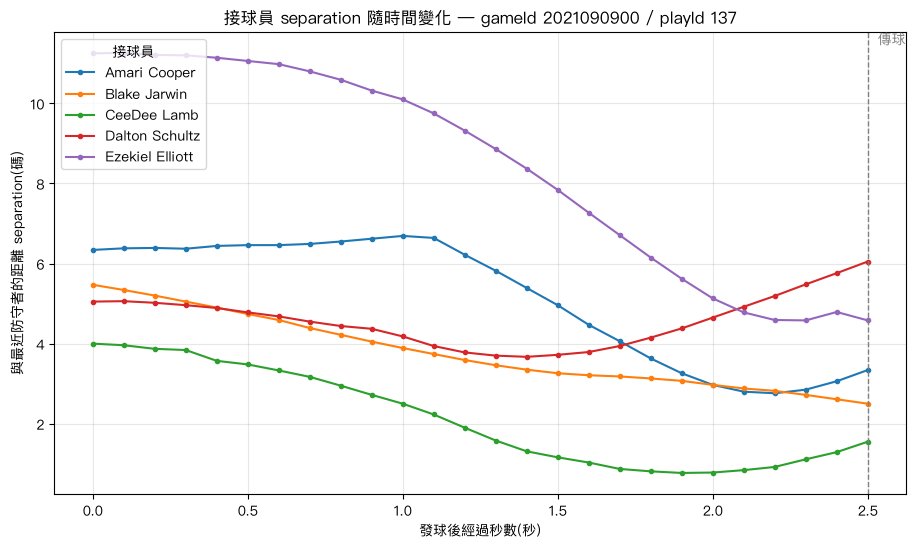

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

for name, g in separation.groupby("receiver"):
    g = g.sort_values("frameId")
    ax.plot(g["seconds_since_snap"], g["separation_yd"], marker="o", markersize=3, label=name)

# 傳球瞬間的垂直虛線
pass_sec = round((pass_frame - snap_frame) * 0.1, 1)
ax.axvline(pass_sec, color="gray", linestyle="--", linewidth=1)
ax.text(pass_sec, ax.get_ylim()[1], "  傳球", va="top", color="gray")

ax.set_xlabel("發球後經過秒數(秒)")
ax.set_ylabel("與最近防守者的距離 separation(碼)")
ax.set_title(f"接球員 separation 隨時間變化 — gameId {SAMPLE_GAME_ID} / playId {SAMPLE_PLAY_ID}")
ax.legend(title="接球員", loc="upper left")
ax.grid(True, alpha=0.3)
plt.show()

## 本階段完成了什麼

- 重建第二階段的 snap → pass 片段(讓本筆記本可獨立執行)。
- 用 `pff_role` 分出接球員(Pass Route)與防守者(Coverage)兩組。
- **核心**:算出每位接球員、每個時間點,到最近防守者的距離(separation),用的是歐氏距離。
- 看了傳球瞬間誰最空,並對照 play 文字描述驗證合理性。
- 畫出 separation 隨時間的折線圖,把座標變成看得懂的空間故事。

**下一階段(等你確認理解後再開始)**:把這套 separation 計算從**一個** play 推廣到**整場 / 多場**,或改用更完整的空間指標(例如控制區 Voronoi)來描述「整片場地被誰控制」,而不只是「最近一個防守者的距離」。